# X-Ray Binary Classification with ResNet-18 (PyTorch)
Classifies chest X-rays into **No Finding** vs **Finding** using a fine-tuned ResNet-18 backbone.

**Dataset:** NIH Chest X-Ray14 (`Data_Entry_2017.csv` + image folders)

Labels are collapsed to:
- `0` → No Finding
- `1` → Finding (any record which isnt 'No finding')

In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob

import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, classification_report
#import labels

# Reproducibility
torch.manual_seed(2024)
np.random.seed(2024)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#model = torch.nn.DataParallel(model, device_ids = [0,1]).to(device)
print('Using device:', DEVICE)

Using device: cuda


In [2]:
print(os.listdir('../input/datasets/organizations/nih-chest-xrays/data'))

['images_003', 'images_012', 'LOG_CHESTXRAY.pdf', 'README_CHESTXRAY.pdf', 'BBox_List_2017.csv', 'images_009', 'images_008', 'images_007', 'test_list.txt', 'images_010', 'ARXIV_V5_CHESTXRAY.pdf', 'images_002', 'images_011', 'Data_Entry_2017.csv', 'images_001', 'train_val_list.txt', 'images_005', 'FAQ_CHESTXRAY.pdf', 'images_004', 'images_006']


In [3]:
from glob import glob
import pandas as pd

csv_path = '../input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
print("CSV exists:", os.path.exists(csv_path))

df = pd.read_csv(csv_path)
print("CSV rows:", df.shape[0])        # should be ~112,000
print("Columns:", df.columns.tolist())

images = glob('../input/datasets/organizations/nih-chest-xrays/data/images*/*/*.png')
print("Images found:", len(images))    # should be ~112,000

CSV exists: True
CSV rows: 112120
Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']
Images found: 112120


Path: ../input/datasets/organizations/nih-chest-xrays/data/images_003/images/00005066_049.png
Size: (1024, 1024)
Mode: L


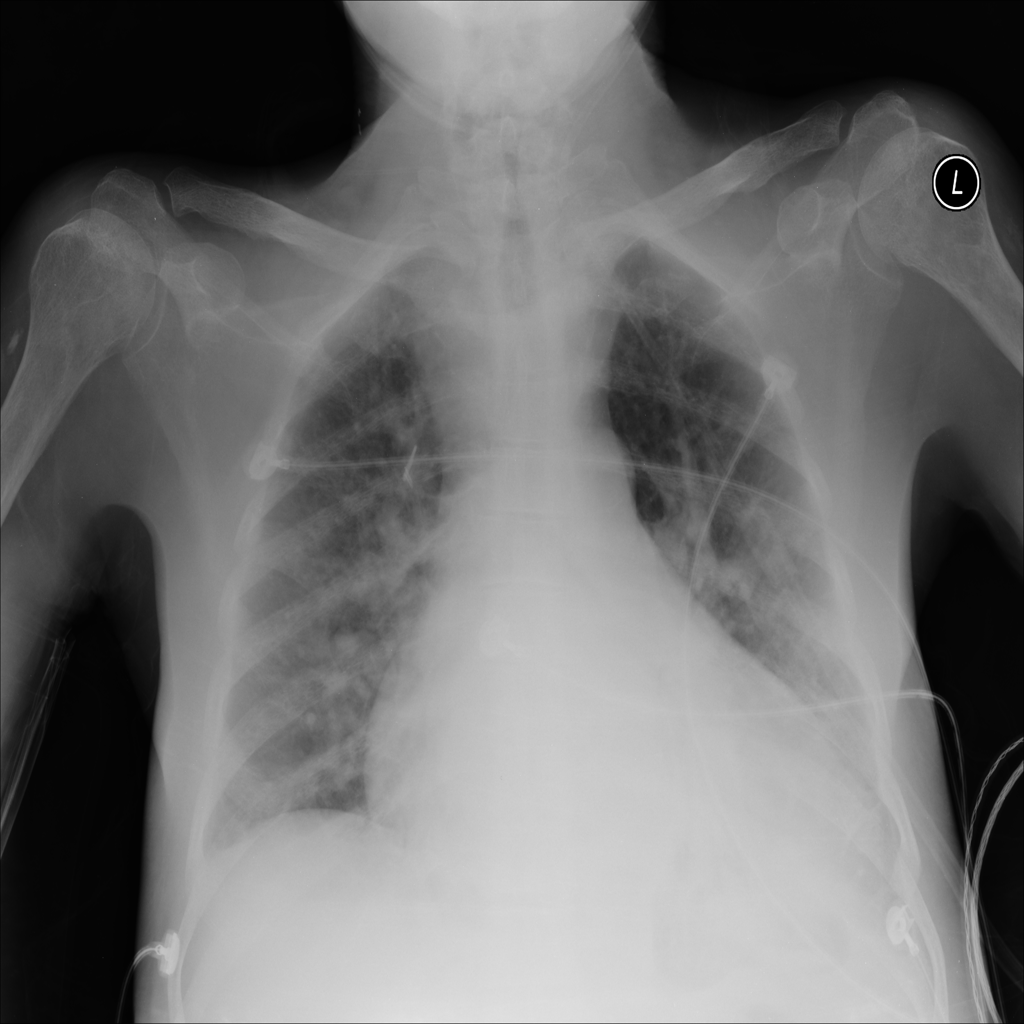

In [4]:
from PIL import Image
# open random image
test_img = np.random.choice(images)
img = Image.open(test_img)
print("Path:", test_img)
print("Size:", img.size)       # e.g. (1024, 1024)
print("Mode:", img.mode)       # should be L (grayscale) or RGB
img

## 1. Load Metadata

In [5]:
# ── Paths ────────────────────────────────────────────────────────────────────
DATA_CSV   = '../input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
IMAGE_GLOB = os.path.join('../input/datasets/organizations/nih-chest-xrays/data/images*/*/*.png')

all_xray_df = pd.read_csv(DATA_CSV)

# Map image filenames → full paths
all_image_paths = {os.path.basename(x): x for x in glob(IMAGE_GLOB)}
print(f'Scans found: {len(all_image_paths)}, Total CSV rows: {all_xray_df.shape[0]}')

all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].astype(str).str.rstrip('Y').astype(int)

all_xray_df.sample(3)
all_xray_df.head()

Scans found: 112120, Total CSV rows: 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,../input/datasets/organizations/nih-chest-xray...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,../input/datasets/organizations/nih-chest-xray...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,../input/datasets/organizations/nih-chest-xray...
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,../input/datasets/organizations/nih-chest-xray...
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,../input/datasets/organizations/nih-chest-xray...


## 2. Label Engineering – Binary: No Finding vs Pneumonia

We keep only rows that are either:
- **No Finding** (label column is exactly `'No Finding'`), or
- **Findings** (label column that dont contain no findings)

This removes multi-label cases, giving the model a clean binary signal.

Class distribution:
binary_label
No Finding    60361
Finding       51759
Name: count, dtype: int64


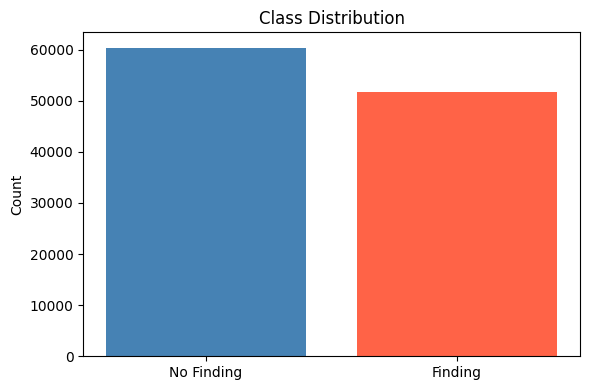


No patient overlap — split is clean
Train:  78566 rows  |  Finding rate: 46.27%
Val:    16106 rows  |  Finding rate: 45.88%
Test:   17448 rows  |  Finding rate: 45.93%


In [6]:
def assign_binary_label(finding: str) -> int | None:
    """Return 0 for No Finding, 1 for Finding, None to drop."""
    if finding == 'No Finding':
        return 0
    else:
        return 1

all_xray_df['binary_label'] = all_xray_df['Finding Labels'].map(assign_binary_label)

# Drop rows without a valid path
binary_df = all_xray_df.dropna(subset=['binary_label', 'path']).copy()
binary_df['binary_label'] = binary_df['binary_label'].astype(int)

print('Class distribution:')
counts = binary_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Finding'})
print(counts)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=['steelblue', 'tomato'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# ── Patient-level split (replaces the old train_test_split calls) ─────────────
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(splitter.split(
    binary_df,
    groups=binary_df['Patient ID']
))

train_df = binary_df.iloc[train_idx].reset_index(drop=True)
temp_df  = binary_df.iloc[temp_idx].reset_index(drop=True)

splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(splitter2.split(
    temp_df,
    groups=temp_df['Patient ID']
))

valid_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df  = temp_df.iloc[test_idx].reset_index(drop=True)

# Verify clean split
assert len(set(train_df['Patient ID']) & set(valid_df['Patient ID'])) == 0
assert len(set(train_df['Patient ID']) & set(test_df['Patient ID']))  == 0
print('\nNo patient overlap — split is clean')
print(f'Train: {len(train_df):6d} rows  |  Finding rate: {train_df["binary_label"].mean():.2%}')
print(f'Val:   {len(valid_df):6d} rows  |  Finding rate: {valid_df["binary_label"].mean():.2%}')
print(f'Test:  {len(test_df):6d} rows  |  Finding rate: {test_df["binary_label"].mean():.2%}')

### 2a. Rebalance – optional downsampling
The NIH dataset has many more 'No Finding' cases. We downsample the majority class to 2× the minority class size to reduce bias without throwing away all negative examples.

In [7]:
'''finding_df  = binary_df[binary_df['binary_label'] == 1]
no_finding_df = binary_df[binary_df['binary_label'] == 0]

# Downsample No Finding to 2× Pneumonia count
n_finding = len(finding_df)
no_finding_sampled = no_finding_df.sample(min(2 * n_finding, len(no_finding_df)), random_state=42)

balanced_df = pd.concat([finding_df, no_finding_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

print('Balanced dataset size:', len(balanced_df))
print(balanced_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Finding'}))'''

"finding_df  = binary_df[binary_df['binary_label'] == 1]\nno_finding_df = binary_df[binary_df['binary_label'] == 0]\n\n# Downsample No Finding to 2× Pneumonia count\nn_finding = len(finding_df)\nno_finding_sampled = no_finding_df.sample(min(2 * n_finding, len(no_finding_df)), random_state=42)\n\nbalanced_df = pd.concat([finding_df, no_finding_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)\n\nprint('Balanced dataset size:', len(balanced_df))\nprint(balanced_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Finding'}))"

## 3. Train / Validation / Test Split

In [8]:
'''train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.30,
    random_state=42,
    stratify=balanced_df['binary_label']
)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['binary_label']
)'''

print(f'Train: {len(train_df)}  |  Val: {len(valid_df)}  |  Test: {len(test_df)}')

Train: 78566  |  Val: 16106  |  Test: 17448


## 4. Dataset & DataLoaders

- Images are loaded as **RGB** (ResNet-18 expects 3 channels).
- Training uses standard augmentations; validation/test use only resize + normalise.
- Normalisation uses ImageNet statistics (mean/std) because ResNet-18 was pre-trained on ImageNet.

In [9]:
IMG_SIZE   = 224   # ResNet-18 default input size
BATCH_SIZE = 256

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class XRayDataset(Dataset):
    """Chest X-Ray binary dataset (No Finding vs Pneumonia)."""

    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        label = torch.tensor(row['binary_label'], dtype=torch.float32)
    
        try:
            image = Image.open(row['path']).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label
        except Exception:
        # Return a blank image instead of crashing
            blank = torch.zeros(3, IMG_SIZE, IMG_SIZE)
            return blank, label


train_dataset = XRayDataset(train_df, transform=train_transforms)
valid_dataset = XRayDataset(valid_df, transform=eval_transforms)
test_dataset  = XRayDataset(test_df,  transform=eval_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2,      # preload 2 batches per worker
    persistent_workers=True # keeps workers alive between epochs
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2,      # preload 2 batches per worker
    persistent_workers=True # keeps workers alive between epochs
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    prefetch_factor=2,      # preload 2 batches per worker
    persistent_workers=True # keeps workers alive between epochs
)

print(f'Batches — train: {len(train_loader)}  val: {len(valid_loader)}  test: {len(test_loader)}')

Batches — train: 1228  val: 252  test: 273


### 4a. Visualise a batch

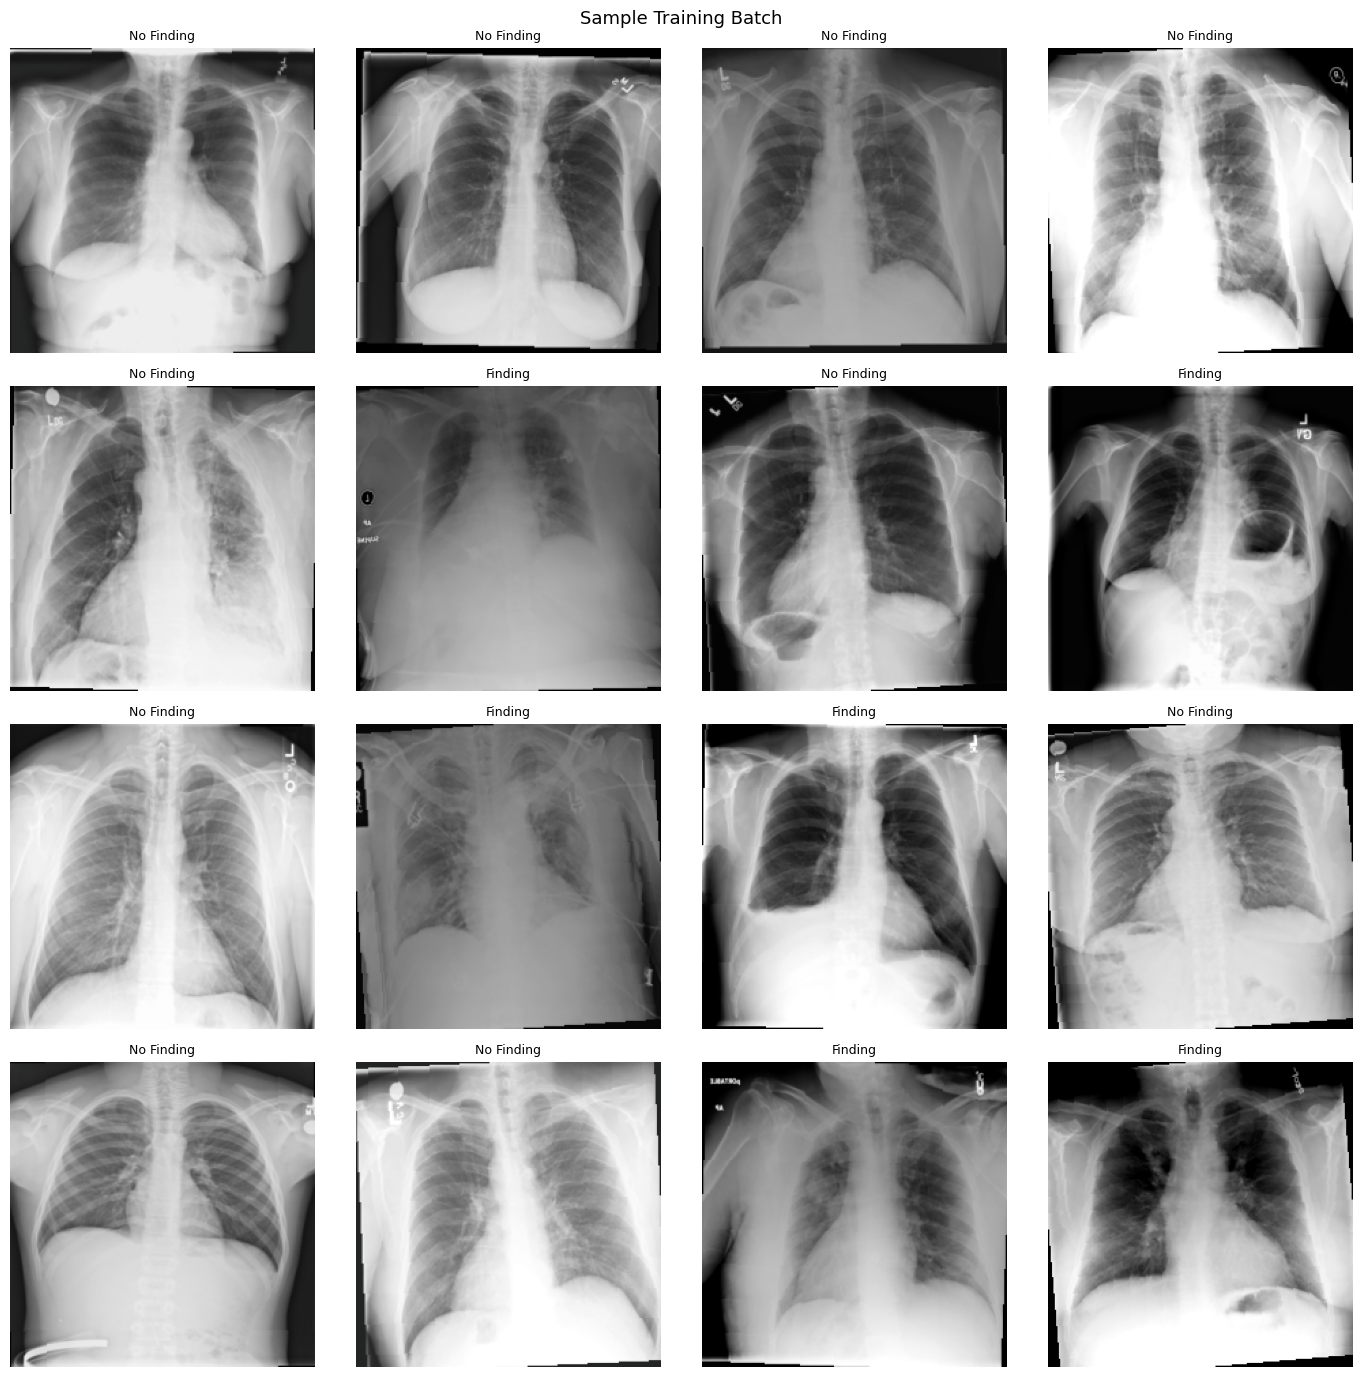

In [10]:
CLASS_NAMES = {0: 'No Finding', 1: 'Finding'}

images, labels = next(iter(train_loader))

def denormalise(tensor):
    """Undo ImageNet normalisation for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
for ax, img, lbl in zip(axes.flatten(), images[:16], labels[:16]):
    img_np = denormalise(img).permute(1, 2, 0).numpy()
    ax.imshow(img_np, cmap='bone')
    ax.set_title(CLASS_NAMES[int(lbl.item())], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Batch', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Build ResNet-18 Model

We load ImageNet pre-trained weights and replace the final fully-connected layer with a **single neuron + sigmoid** for binary classification. The rest of the network is fine-tuned.

In [11]:
if torch.cuda.is_available():
    x = torch.randn(2, 3).cuda()
    print(x)

tensor([[-0.8140,  1.3722,  0.5060],
        [-0.4823, -0.7853,  0.6681]], device='cuda:0')


In [12]:
def build_resnet18(freeze_backbone: bool = False) -> nn.Module:
    """
    ResNet-18 with a custom binary classification head.

    Args:
        freeze_backbone: If True, only the classification head is trained
                         (useful for a warm-up phase).
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the default 1000-class head
    in_features = model.fc.in_features   # 512 for ResNet-18
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, 1),               # single output
        nn.Sigmoid()
    )

    return model

model = build_resnet18(freeze_backbone=False).to(DEVICE)

# Quick sanity check
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out   = model(dummy)
    print('Output shape:', out.shape)   # should be [2, 1]

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,}  |  Trainable: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 151MB/s]


Output shape: torch.Size([2, 1])
Total params: 11,308,097  |  Trainable: 11,308,097


## 6. Loss, Optimiser & Scheduler

We use **BCELoss** (binary cross-entropy) with `pos_weight` to further compensate for any remaining class imbalance.

In [13]:
# Compute positive class weight from training set
n_neg = (train_df['binary_label'] == 0).sum()
n_pos = (train_df['binary_label'] == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f'pos_weight: {pos_weight.item():.3f}  (neg={n_neg}, pos={n_pos})')

criterion = nn.BCELoss(weight=None)   # sigmoid is already in the model
# Alternatively: nn.BCEWithLogitsLoss(pos_weight=pos_weight) if you remove Sigmoid from the head

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Reduce LR on plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2)

pos_weight: 1.161  (neg=42210, pos=36356)


## 7. Training Loop

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = (outputs >= 0.5).float()
        correct += (preds == labels).sum().item()
        total   += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = (outputs >= 0.5).float()
        correct += (preds == labels).sum().item()
        total   += images.size(0)

        all_preds.append(outputs.cpu())
        all_labels.append(labels.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    return total_loss / total, correct / total, all_preds, all_labels

In [15]:
train_patients = set(train_df['Patient ID'].values)
val_patients   = set(valid_df['Patient ID'].values)
overlap        = train_patients & val_patients

print(f'Overlapping patients: {len(overlap)}')
print(f'Train patients: {len(train_patients)}')
print(f'Val patients:   {len(val_patients)}')

Overlapping patients: 0
Train patients: 21563
Val patients:   4621


In [16]:
from tqdm import tqdm

NUM_EPOCHS    = 10
BEST_VAL_LOSS = float('inf')
CHECKPOINT    = 'resnet18_xray_best.pth'
PATIENCE      = 4
patience_ctr  = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc='  Training', leave=False,
                bar_format='{l_bar}{bar:30}{r_bar}')

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = (outputs >= 0.5).float()
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

        # Live loss + acc in the progress bar
        pbar.set_postfix({
            'loss': f'{total_loss / total:.4f}',
            'acc':  f'{correct / total:.4f}'
        })

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc='  Validating', leave=False,
                bar_format='{l_bar}{bar:30}{r_bar}')

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds       = (outputs >= 0.5).float()
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
        all_preds.append(outputs.cpu())
        all_labels.append(labels.cpu())

        pbar.set_postfix({
            'loss': f'{total_loss / total:.4f}',
            'acc':  f'{correct / total:.4f}'
        })

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return total_loss / total, correct / total, all_preds, all_labels


for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\nEpoch {epoch:02d}/{NUM_EPOCHS}')

    train_loss, train_acc         = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss,   val_acc, _, _     = evaluate(model, valid_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    improved = val_loss < BEST_VAL_LOSS
    if improved:
        BEST_VAL_LOSS = val_loss
        torch.save(model.state_dict(), CHECKPOINT)
        patience_ctr = 0
    else:
        patience_ctr += 1

    flag = ' ← best' if improved else ''
    print(f'  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping after {epoch} epochs.')
        break

print('\nTraining complete. Best val_loss:', round(BEST_VAL_LOSS, 4))


Epoch 01/10


  train_loss=0.6047  train_acc=0.6876  val_loss=0.5917  val_acc=0.6966 ← best

Epoch 02/10


  train_loss=0.5849  train_acc=0.7054  val_loss=0.5821  val_acc=0.7060 ← best

Epoch 03/10


  train_loss=0.5765  train_acc=0.7128  val_loss=0.5795  val_acc=0.7050 ← best

Epoch 04/10


  train_loss=0.5699  train_acc=0.7159  val_loss=0.5730  val_acc=0.7130 ← best

Epoch 05/10


  train_loss=0.5636  train_acc=0.7214  val_loss=0.5830  val_acc=0.7066

Epoch 06/10


  train_loss=0.5573  train_acc=0.7265  val_loss=0.5815  val_acc=0.7097

Epoch 07/10


  train_loss=0.5485  train_acc=0.7311  val_loss=0.5761  val_acc=0.7106

Epoch 08/10


  train_loss=0.5233  train_acc=0.7479  val_loss=0.5853  val_acc=0.7086
Early stopping after 8 epochs.

Training complete. Best val_loss: 0.573


## 8. Training Curves

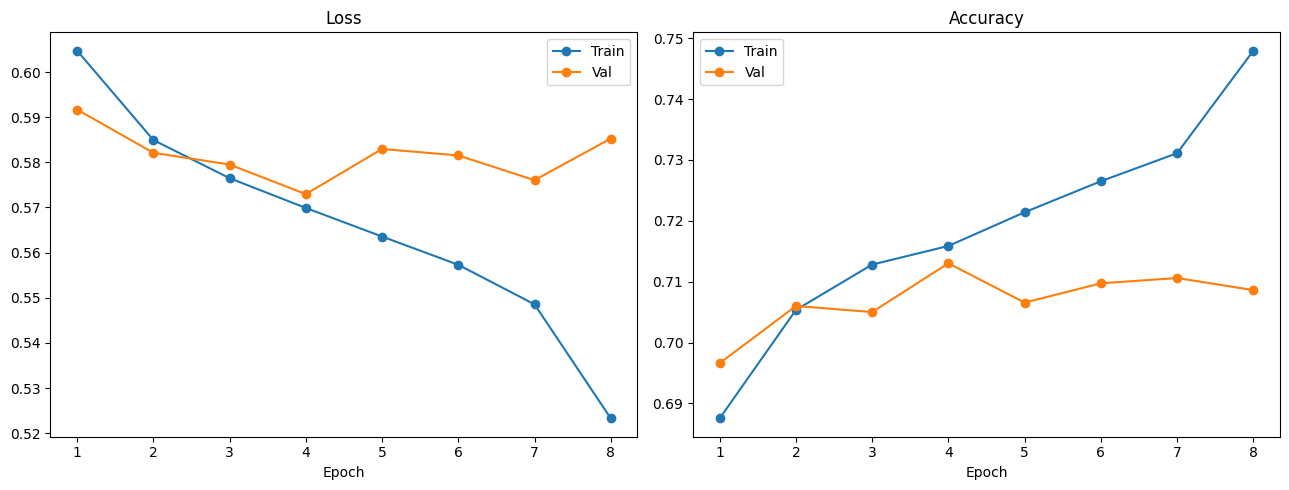

In [17]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(epochs_ran, history['train_loss'], label='Train', marker='o')
ax1.plot(epochs_ran, history['val_loss'],   label='Val',   marker='o')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epochs_ran, history['train_acc'], label='Train', marker='o')
ax2.plot(epochs_ran, history['val_acc'],   label='Val',   marker='o')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()

## 9. Evaluate on Test Set

In [18]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))

test_loss, test_acc, pred_probs, true_labels = evaluate(model, test_loader, criterion, DEVICE)
pred_binary = (pred_probs >= 0.5).astype(int)

print(f'Test Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc:.4f}\n')
print(classification_report(true_labels.astype(int), pred_binary,
                             target_names=['No Finding', 'Finding']))

Test Loss: 0.5700  |  Test Accuracy: 0.7131

              precision    recall  f1-score   support

  No Finding       0.74      0.73      0.73      9434
     Finding       0.69      0.69      0.69      8014

    accuracy                           0.71     17448
   macro avg       0.71      0.71      0.71     17448
weighted avg       0.71      0.71      0.71     17448



## 10. ROC Curve

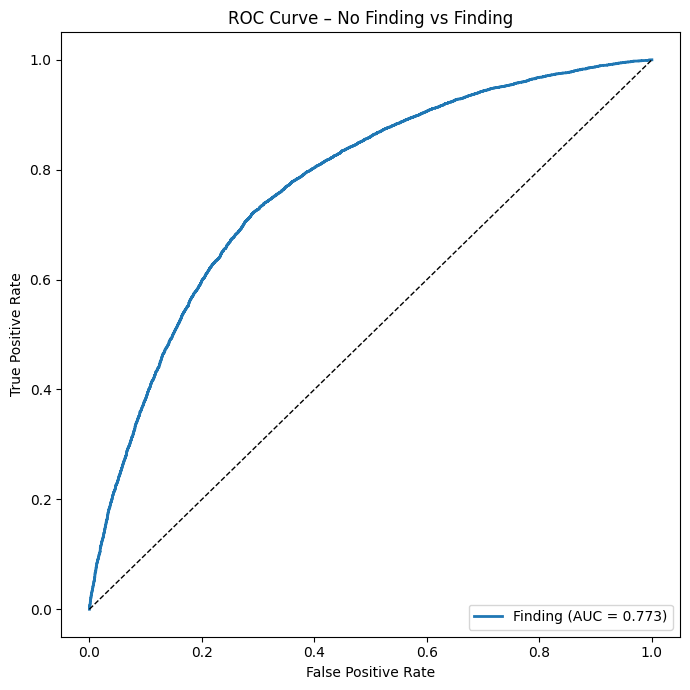

In [19]:
fpr, tpr, _ = roc_curve(true_labels.astype(int), pred_probs)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, label=f'Finding (AUC = {roc_auc:.3f})', lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve – No Finding vs Finding')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()

## 11. Show Predictions on Sample Images

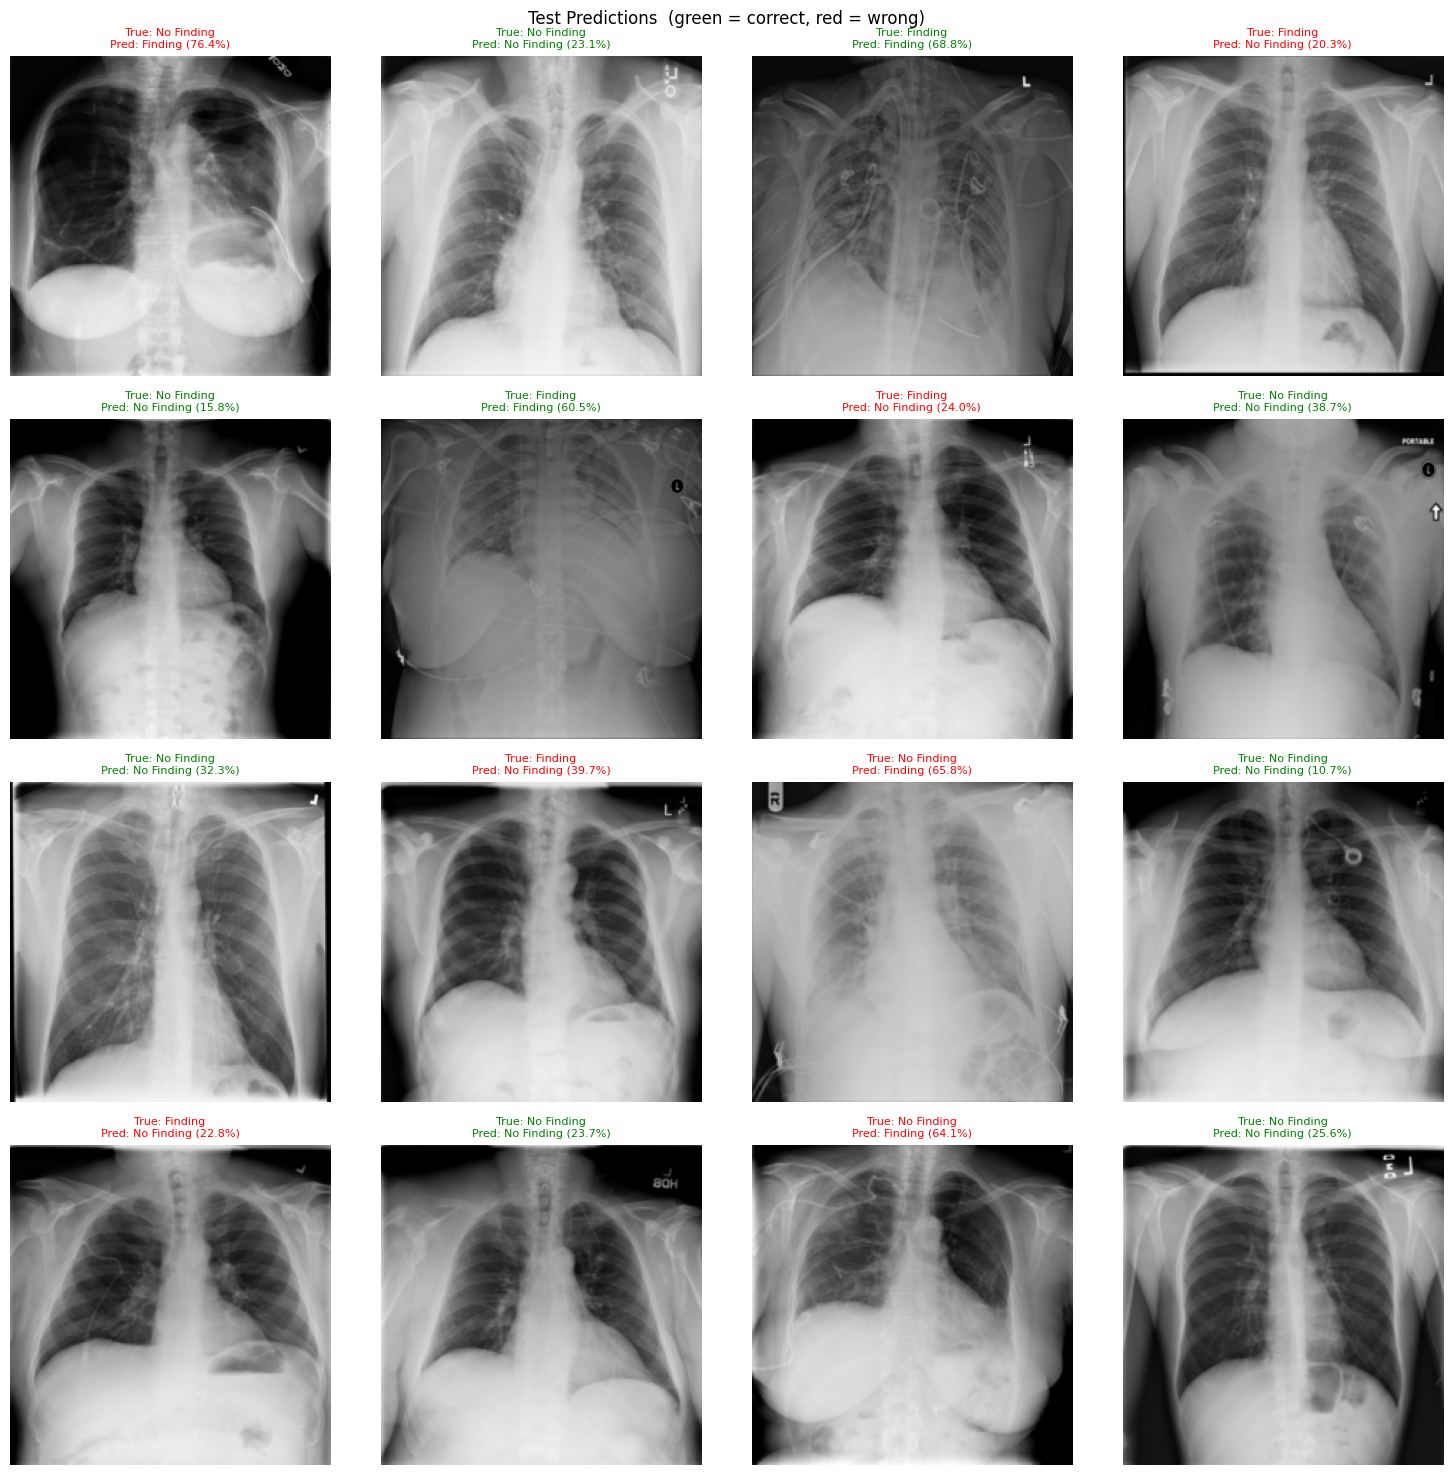

In [20]:
model.eval()
sample_images, sample_labels = next(iter(test_loader))
sample_images_dev = sample_images.to(DEVICE)

with torch.no_grad():
    sample_probs = model(sample_images_dev).cpu().squeeze().numpy()

n_show = 16
fig, axes = plt.subplots(4, 4, figsize=(15, 15))

for ax, img, true_lbl, prob in zip(axes.flatten(),
                                    sample_images[:n_show],
                                    sample_labels[:n_show],
                                    sample_probs[:n_show]):
    img_np    = denormalise(img).permute(1, 2, 0).numpy()
    pred_lbl  = int(prob >= 0.5)
    true_str  = CLASS_NAMES[int(true_lbl.item())]
    pred_str  = CLASS_NAMES[pred_lbl]
    colour    = 'green' if pred_lbl == int(true_lbl.item()) else 'red'

    ax.imshow(img_np, cmap='bone')
    ax.set_title(f'True: {true_str}\nPred: {pred_str} ({prob:.1%})',
                 color=colour, fontsize=8)
    ax.axis('off')

plt.suptitle('Test Predictions  (green = correct, red = wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('test_predictions.png', dpi=120)
plt.show()

## 12. Save the Final Model

In [21]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      CLASS_NAMES,
    'img_size':         IMG_SIZE,
    'test_accuracy':    round(test_acc, 4),
    'test_auc':         round(roc_auc, 4),
}, '../kaggle/working/resnet18_xray_final.pth')

print('Model saved to /kaggle/working/resnet18_xray_final.pth')

RuntimeError: Parent directory ../kaggle/working does not exist.